# Replica Exchange: PF00041 & PF00072 / PF00004 & PF00072

20x20 temperature grid replica exchange for two Pfam pairs at specific overlaps:
- PF00041 & PF00072, overlap = 218 nt
- PF00004 & PF00072, overlap = 217 nt

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": ".9", "grid.linestyle": "--",
                             "axes.edgecolor": ".6", "xtick.bottom": True, "ytick.left": True})

from overlappingGenes import extract_params, load_natural_energies
from replica_exchange import make_temperature_grid, replica_exchange, analyze_replicas

from matplotlib.colors import BoundaryNorm, ListedColormap


In [13]:
def within_and_distance(pareto_front, mu1, sig1, mu2, sig2):
    """Returns (within_pareto, zscore_distance)."""
    natural_mean = np.array([mu1, mu2])
    pz = np.array([(natural_mean[0] - mu1) / sig1, (natural_mean[1] - mu2) / sig2])  # (0, 0)

    # Check if dominated by Pareto front
    within = False
    for pf_point in pareto_front:
        fz = np.array([(pf_point[0] - mu1) / sig1, (pf_point[1] - mu2) / sig2])
        if (fz[0] <= pz[0] and fz[1] <= pz[1] and
                (fz[0] < pz[0] or fz[1] < pz[1])):
            within = True
            break
    # Also check if on front
    if not within:
        for pf_point in pareto_front:
            fz = np.array([(pf_point[0] - mu1) / sig1, (pf_point[1] - mu2) / sig2])
            if abs(fz[0] - pz[0]) < 1e-6 and abs(fz[1] - pz[1]) < 1e-6:
                within = True
                break

    pf_z = np.array([[(p[0] - mu1) / sig1, (p[1] - mu2) / sig2] for p in pareto_front])
    distances = np.sqrt(np.sum(pf_z**2, axis=1))
    zscore_dist = -float(np.min(distances)) if within else float(np.min(distances))
    return within, zscore_dist

In [14]:
def run_pair(pf1_name, pf2_name, overlap_nuc, M=20):
    """Load DCA params, run replica exchange, return everything needed for plots."""
    bmDCA_dir = "../../0 bmDCA/"

    J1, h1 = extract_params(f"{bmDCA_dir}{pf1_name}/{pf1_name}_params.dat")
    J2, h2 = extract_params(f"{bmDCA_dir}{pf2_name}/{pf2_name}_params.dat")
    DCA_1 = [J1, h1]
    DCA_2 = [J2, h2]

    L1 = len(h1) // 21
    L2 = len(h2) // 21

    ne1 = load_natural_energies(f"{bmDCA_dir}{pf1_name}/{pf1_name}_naturalenergies.txt")
    ne2 = load_natural_energies(f"{bmDCA_dir}{pf2_name}/{pf2_name}_naturalenergies.txt")
    mu1, sig1 = np.mean(ne1), np.std(ne1)
    mu2, sig2 = np.mean(ne2), np.std(ne2)

    print(f"{pf1_name}: L = {L1} AA,  <E> = {mu1:.1f} +/- {sig1:.1f}")
    print(f"{pf2_name}: L = {L2} AA,  <E> = {mu2:.1f} +/- {sig2:.1f}")
    print(f"Overlap: {overlap_nuc} nt")

    T1_vals, T2_vals = make_temperature_grid(T_min=0.1, T_max=2.0, M1=M, M2=M) # old Tmin = 0.1
    print(f"Temperature grid: {M}x{M} = {M*M} replicas")

    re_results = replica_exchange(
        DCA_1, DCA_2, L1, L2, overlap_nuc,
        T1_vals, T2_vals,
        N_swap=1000,
        N_total=500_000, # old 500k
        N_equil=100_000,
        N_thin=1000,
        discard_frac=0.2,
        quiet=False,
    )

    analysis = analyze_replicas(re_results, mu1, sig1, mu2, sig2)
    within, zscore_dist = within_and_distance(analysis["pareto_front"], mu1, sig1, mu2, sig2)

    print(f"\nOptimal temperatures: T1* = {analysis['T1_opt']:.3f}, T2* = {analysis['T2_opt']:.3f}")
    print(f"Pareto front: {len(analysis['pareto_front'])} points")
    print(f"Within Pareto front: {within}")
    print(f"Z-score distance: {zscore_dist:.3f}")

    return {
        "pf1": pf1_name, "pf2": pf2_name, "overlap_nuc": overlap_nuc,
        "re_results": re_results, "analysis": analysis,
        "mu1": mu1, "sig1": sig1, "mu2": mu2, "sig2": sig2,
        "T1_vals": T1_vals, "T2_vals": T2_vals,
        "M": M, "within": within, "zscore_dist": zscore_dist,
    }

In [15]:
def plot_zscore_heatmaps(run):
    """Plot z-score heatmaps for both proteins."""
    analysis = run["analysis"]
    T1_vals, T2_vals = run["T1_vals"], run["T2_vals"]
    M = run["M"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Flat colour bar
    cmap = ListedColormap(["tab:blue", "white", "tab:red"])
    bounds = [-np.inf, -0.5, 0.5, np.inf]
    norm = BoundaryNorm(bounds, cmap.N) 

    # z1 grid
    im0 = axes[0].imshow(analysis["z1_grid"], origin="lower", aspect="auto",
                        #  cmap=cmap, norm=norm)
                        cmap="RdBu_r", vmin=-3, vmax=3)
    axes[0].set_xticks(range(0, M, max(1, M//5)))
    axes[0].set_xticklabels([f"{T2_vals[i]:.2f}" for i in range(0, M, max(1, M//5))], rotation=45)
    axes[0].set_yticks(range(0, M, max(1, M//5)))
    axes[0].set_yticklabels([f"{T1_vals[i]:.2f}" for i in range(0, M, max(1, M//5))])
    axes[0].set_xlabel("$T_2$")
    axes[0].set_ylabel("$T_1$")
    axes[0].set_title(f"$z_1$ ({run['pf1']})")
    axes[0].grid(False)
    plt.colorbar(im0, ax=axes[0])

    # z2 grid
    im1 = axes[1].imshow(analysis["z2_grid"], origin="lower", aspect="auto",
                        #  cmap=cmap, norm=norm)
                          cmap="RdBu_r", vmin=-3, vmax=3)
    axes[1].set_xticks(range(0, M, max(1, M//5)))
    axes[1].set_xticklabels([f"{T2_vals[i]:.2f}" for i in range(0, M, max(1, M//5))], rotation=45)
    axes[1].set_yticks(range(0, M, max(1, M//5)))
    axes[1].set_yticklabels([f"{T1_vals[i]:.2f}" for i in range(0, M, max(1, M//5))])
    axes[1].set_xlabel("$T_2$")
    axes[1].set_ylabel("$T_1$")
    axes[1].set_title(f"$z_2$ ({run['pf2']})")
    axes[1].grid(False)
    plt.colorbar(im1, ax=axes[1])

    # |z1| + |z2|
    combined = np.abs(analysis["z1_grid"]) + np.abs(analysis["z2_grid"])

    best = np.unravel_index(np.nanargmin(combined), combined.shape)
    axes[0].plot(best[1], best[0], "*", color="white", ms=15, mew=1.5)
    axes[1].plot(best[1], best[0], "*", color="white", ms=15, mew=1.5)
    # axes[2].plot(best[1], best[0], "*", color="white", ms=15, mew=1.5)

    # fig.suptitle(f"{run['pf1']} & {run['pf2']}  (overlap = {run['overlap_nuc']} nt)", fontsize=15, y=1.02)
    plt.tight_layout()

    # plt.savefig(f"20260327 Replica Panels/20260327_zMaps_{run['pf1']}_{run['pf2']}_overlap{run['overlap_nuc']}nt.svg", dpi=300)
    plt.show()

In [16]:
def plot_pareto(run, pltlim = None):
    """Plot scatter of all samples + Pareto front + shaded dominated region + natural mean."""
    analysis = run["analysis"]
    samples = run["re_results"]["samples"]
    pf = analysis["pareto_front"]  # sorted by E1 ascending
    mu1, sig1 = run["mu1"], run["sig1"]
    mu2, sig2 = run["mu2"], run["sig2"]
    M = run["M"]

    fig, ax = plt.subplots(figsize=(6, 5))

    all_E1, all_E2 = [], []
    for a in range(M):
        for b in range(M):
            all_E1.extend(samples[(a, b)]["E1"].tolist())
            all_E2.extend(samples[(a, b)]["E2"].tolist())
    ax.scatter(all_E1, all_E2, s=1, alpha=0.1, color="gray", rasterized=True)

    # # Shade the dominated region (upper-right of front)
    # # Build polygon: front curve, then close via upper-right corner of plot
    # pad = 0.05  # fraction of range for padding
    # x_all = np.array(all_E1 + [mu1])
    # y_all = np.array(all_E2 + [mu2])
    # x_max = np.max(x_all) + pad * np.ptp(x_all)
    # y_max = np.max(y_all) + pad * np.ptp(y_all)

    # poly_x = np.concatenate([[pf[0, 0]], pf[:, 0], [x_max, x_max, pf[0, 0]]])
    # poly_y = np.concatenate([[y_max], pf[:, 1], [pf[-1, 1], y_max, y_max]])
    # ax.fill(poly_x, poly_y, color="gray", alpha=0.15, zorder=0, label="dominated region")

    # ax.plot(pf[:, 0], pf[:, 1], "-", color="k", lw=.2, label="Pareto front", rasterized=True)

    # Natural mean cross-hair (1 std dev arms)
    ax.plot([mu1 - sig1, mu1 + sig1], [mu2, mu2], "-", color="k", alpha=1, rasterized=True)
    ax.plot([mu1, mu1], [mu2 - sig2, mu2 + sig2], "-", color="k", alpha=1, rasterized=True)
    ax.plot(mu1, mu2, "o", color="k", ms=10, mew=2, label="natural mean")

    # Natural means as axes lines
    ax.axvline(mu1, color="k", alpha=1, ls="--")
    ax.axhline(mu2, color="k", alpha=1, ls="--")

    ax.set_xlabel(f"$E_1$ ({run['pf1']})")
    ax.set_ylabel(f"$E_2$ ({run['pf2']})")
    # ax.set_title(f"Pareto front  (overlap = {run['overlap_nuc']} nt)")

    if pltlim is not None:
        plt.xlim(pltlim[0], pltlim[1])
        plt.ylim(pltlim[2], pltlim[3])
    else:
        plt.ylim(bottom=min(y_all), top=max(y_all) + pad * np.ptp(y_all))
        plt.xlim(left=min(x_all), right=max(x_all) + pad * np.ptp(x_all))
        print(f"y-lim: {plt.ylim()}")
        print(f"x-lim: {plt.xlim()}")

    ax.grid(False)

    # ax.legend(fontsize=11)
    plt.savefig(f"20260327_Pareto_{run['pf1']}_{run['pf2']}_overlap{run['overlap_nuc']}nt.svg", dpi=300)
    plt.tight_layout()
    plt.show()

---
## PF00041 & PF00072 — overlap = 218 nt

In [17]:
%%time
run1 = run_pair("PF00041", "PF00072", overlap_nuc=218, M=20)

PF00041: L = 74 AA,  <E> = 120.7 +/- 17.6
PF00072: L = 108 AA,  <E> = 201.4 +/- 30.0
Overlap: 218 nt
Temperature grid: 20x20 = 400 replicas
Initialised 400 replicas, each equilibrated for 100000 steps (20 workers)
  Round 50/500
  Round 100/500
  Round 150/500
  Round 200/500
  Round 250/500
  Round 300/500
  Round 350/500
  Round 400/500
  Round 450/500
  Round 500/500

Optimal temperatures: T1* = 0.777, T2* = 0.909
Pareto front: 308 points
Within Pareto front: True
Z-score distance: -2.289
CPU times: user 31 s, sys: 2.72 s, total: 33.7 s
Wall time: 42.4 s


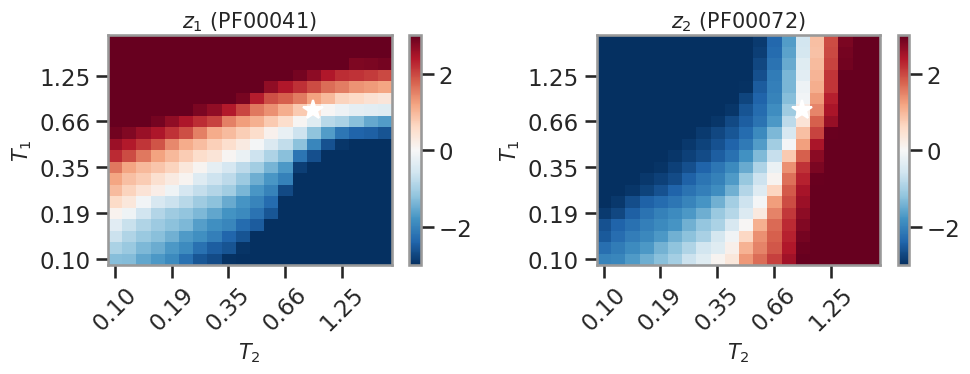

In [18]:
plot_zscore_heatmaps(run1)

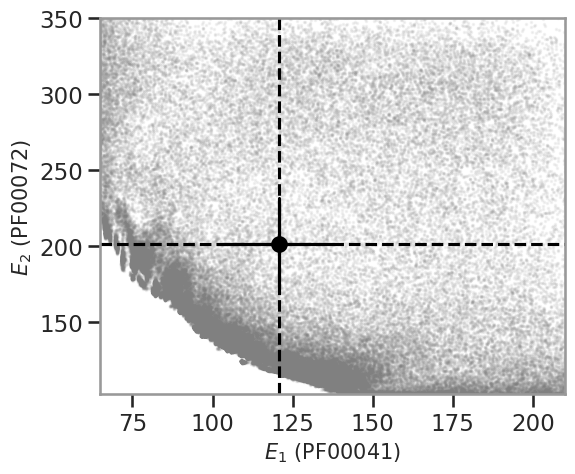

In [19]:
plot_pareto(run1, pltlim=[65, 210, 102, 350])

---
## PF00004 & PF00072 — overlap = 217 nt

In [20]:
%%time
run2 = run_pair("PF00004", "PF00072", overlap_nuc=217, M=20)

PF00004: L = 110 AA,  <E> = 145.9 +/- 38.2
PF00072: L = 108 AA,  <E> = 201.4 +/- 30.0
Overlap: 217 nt
Temperature grid: 20x20 = 400 replicas
Initialised 400 replicas, each equilibrated for 100000 steps (20 workers)
  Round 50/500
  Round 100/500
  Round 150/500
  Round 200/500
  Round 250/500
  Round 300/500
  Round 350/500
  Round 400/500
  Round 450/500
  Round 500/500

Optimal temperatures: T1* = 0.100, T2* = 0.137
Pareto front: 428 points
Within Pareto front: False
Z-score distance: 0.220
CPU times: user 33.8 s, sys: 3.14 s, total: 36.9 s
Wall time: 45.1 s


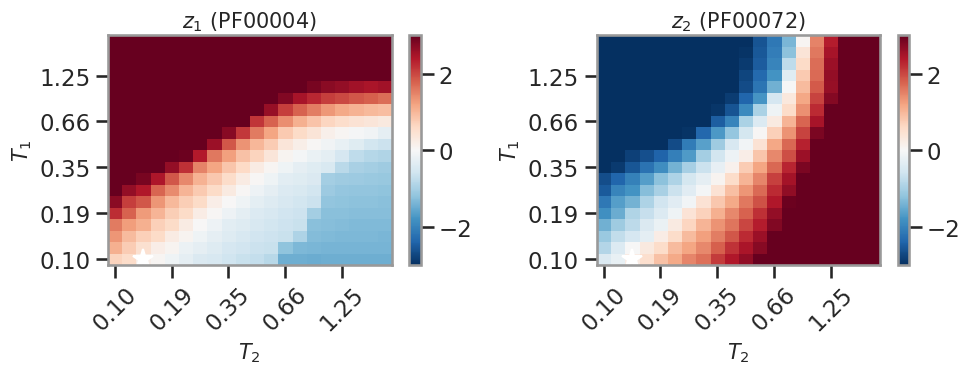

In [21]:
plot_zscore_heatmaps(run2)

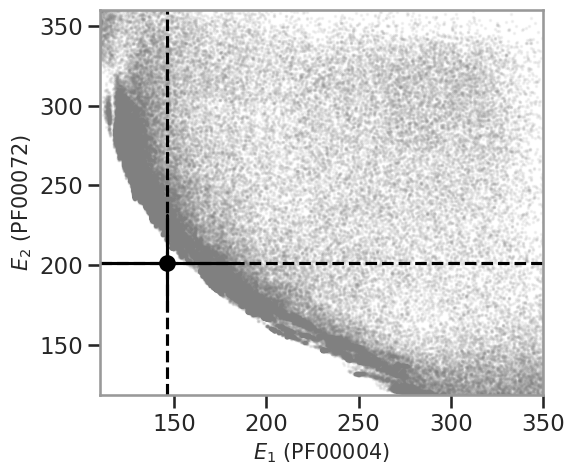

In [22]:
plot_pareto(run2, pltlim=[110, 350, 118, 360])